In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os
import glob

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("Libraries imported successfully")

ModuleNotFoundError: No module named 'scipy'

In [3]:
%pip install scipy

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os
import glob

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
nav_file = "../Core-Data-Analytics-Foundation/Data/Raw/02_nav_history.csv"

nav_df = pd.read_csv(nav_file)

print("NAV data loaded successfully")
print("Shape:", nav_df.shape)

display(nav_df.head())

NAV data loaded successfully
Shape: (46000, 3)


,amfi_code,date,nav
0,119551,03-01-2022,54.385600
1,119551,04-01-2022,54.347400
2,119551,05-01-2022,54.686900
3,119551,06-01-2022,55.455000
4,119551,07-01-2022,55.369200


In [3]:
print("Columns:", nav_df.columns.tolist())
print("Number of schemes:", nav_df["amfi_code"].nunique())
print("Date range:", nav_df["date"].min(), "to", nav_df["date"].max())

Columns: ['amfi_code', 'date', 'nav']
Number of schemes: 40
Date range: 01-01-2024 to 31-12-2025


In [4]:
nav_df["date"] = pd.to_datetime(
    nav_df["date"],
    dayfirst=True,
    errors="coerce"
)

nav_df["nav"] = pd.to_numeric(
    nav_df["nav"],
    errors="coerce"
)

nav_df = nav_df.dropna(
    subset=["amfi_code", "date", "nav"]
)

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

print("Cleaned shape:", nav_df.shape)
print("Schemes:", nav_df["amfi_code"].nunique())
print("Date range:", nav_df["date"].min(), "to", nav_df["date"].max())

Cleaned shape: (46000, 3)
Schemes: 40
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [5]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

display(nav_df.head(10))

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.460800,NaN
1,100016,2022-01-04,515.097100,-0.010306
2,100016,2022-01-05,521.723900,0.012865
3,100016,2022-01-06,515.788000,-0.011377
4,100016,2022-01-07,515.163900,-0.001210
5,100016,2022-01-10,510.713600,-0.008639
6,100016,2022-01-11,513.554200,0.005562
7,100016,2022-01-12,512.319500,-0.002404
8,100016,2022-01-13,510.244500,-0.004050
9,100016,2022-01-14,514.363600,0.008073


In [6]:
print("Daily return statistics:")
display(nav_df["daily_return"].describe())

print("\nMinimum daily return:",
      nav_df["daily_return"].min())

print("Maximum daily return:",
      nav_df["daily_return"].max())

print("Missing daily returns:",
      nav_df["daily_return"].isna().sum())

Daily return statistics:


count   45960.000000
mean        0.000631
std         0.010290
min        -0.058102
25%        -0.005042
50%         0.000340
75%         0.006324
max         0.064713
Name: daily_return, dtype: float64


Minimum daily return: -0.058102013949189124
Maximum daily return: 0.06471309359097144
Missing daily returns: 40


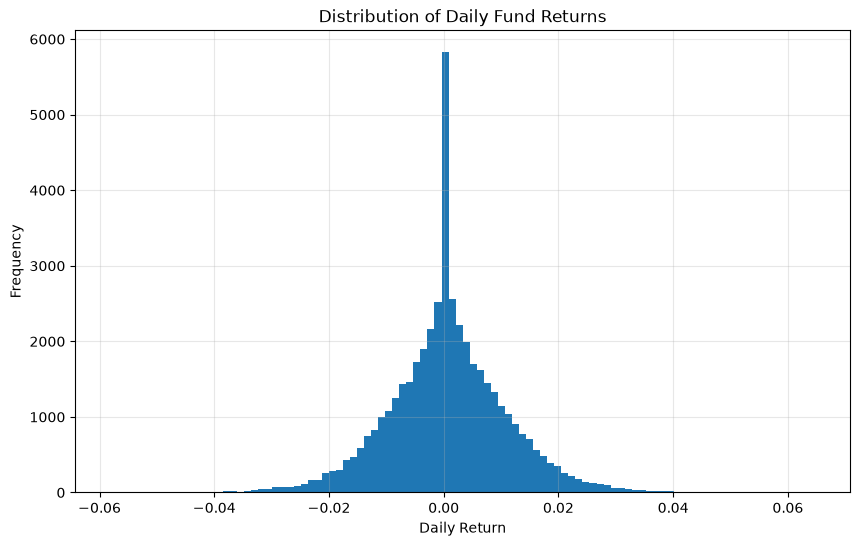

In [7]:
plt.figure(figsize=(10, 6))

plt.hist(
    nav_df["daily_return"].dropna(),
    bins=100
)

plt.title("Distribution of Daily Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

In [8]:
# Calculate 1-year CAGR for all 40 funds

end_date = nav_df["date"].max()
start_date_1y = end_date - pd.DateOffset(years=1)

cagr_1y = []

for fund, group in nav_df.groupby("amfi_code"):
    group = group.sort_values("date")

    start_data = group[group["date"] >= start_date_1y]
    
    if len(start_data) == 0:
        continue

    start_nav = start_data.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    actual_days = (
        group.iloc[-1]["date"] - start_data.iloc[0]["date"]
    ).days

    if start_nav > 0 and actual_days > 0:
        cagr = (end_nav / start_nav) ** (365.25 / actual_days) - 1
    else:
        cagr = np.nan

    cagr_1y.append({
        "amfi_code": fund,
        "cagr_1y": cagr
    })

cagr_1y_df = pd.DataFrame(cagr_1y)

cagr_1y_df = cagr_1y_df.sort_values(
    "cagr_1y",
    ascending=False
).reset_index(drop=True)

display(cagr_1y_df)

,amfi_code,cagr_1y
0,119598,0.828516
1,149324,0.651955
2,119551,0.604893
3,100033,0.532772
4,101206,0.479638
5,120506,0.418530
6,148569,0.397838
7,118632,0.340079
8,120505,0.296277
9,125497,0.286976


In [9]:
cagr_1y_df["cagr_1y_pct"] = cagr_1y_df["cagr_1y"] * 100

display(
    cagr_1y_df[
        ["amfi_code", "cagr_1y_pct"]
    ].round(2)
)

,amfi_code,cagr_1y_pct
0,119598,82.850000
1,149324,65.200000
2,119551,60.490000
3,100033,53.280000
4,101206,47.960000
5,120506,41.850000
6,148569,39.780000
7,118632,34.010000
8,120505,29.630000
9,125497,28.700000


In [16]:
print("Shape of cagr_1y_df:", cagr_1y_df.shape)

Shape of cagr_1y_df: (40, 3)


In [17]:
print("Shape of cagr_1y_df:", cagr_1y_df.shape)

Shape of cagr_1y_df: (40, 3)


In [18]:
display(cagr_1y_df.head(10))

,amfi_code,cagr_1y,cagr_1y_pct
0,119598,0.828516,82.851575
1,149324,0.651955,65.195466
2,119551,0.604893,60.489297
3,100033,0.532772,53.277195
4,101206,0.479638,47.963794
5,120506,0.418530,41.852990
6,148569,0.397838,39.783803
7,118632,0.340079,34.007896
8,120505,0.296277,29.627681
9,125497,0.286976,28.697580


In [19]:
display(cagr_1y_df.head(10))

,amfi_code,cagr_1y,cagr_1y_pct
0,119598,0.828516,82.851575
1,149324,0.651955,65.195466
2,119551,0.604893,60.489297
3,100033,0.532772,53.277195
4,101206,0.479638,47.963794
5,120506,0.418530,41.852990
6,148569,0.397838,39.783803
7,118632,0.340079,34.007896
8,120505,0.296277,29.627681
9,125497,0.286976,28.697580


In [20]:
scheme_file = "../Core-Data-Analytics-Foundation/Data/Raw/07_scheme_performance.csv"

scheme_df = pd.read_csv(scheme_file)

print("Shape:", scheme_df.shape)
print("Columns:", scheme_df.columns.tolist())

display(scheme_df.head())

Shape: (40, 19)
Columns: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.420000,12.360000,14.450000,11.490000,0.870000,0.890000,0.880000,1.290000,14.000000,-21.700000,14288,1.540000,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.250000,11.300000,14.230000,9.520000,1.780000,0.870000,0.810000,1.290000,14.000000,-24.430000,1231,0.660000,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.560000,23.390000,20.670000,22.160000,1.230000,0.890000,0.940000,1.350000,25.000000,-13.350000,19259,1.430000,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.590000,23.140000,21.820000,22.010000,1.130000,1.040000,0.930000,1.670000,25.000000,-24.780000,36061,0.720000,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.340000,6.070000,5.430000,4.470000,1.600000,0.220000,1.520000,2.110000,4.000000,-2.300000,24101,0.770000,5,Low


In [21]:
for i, col in enumerate(scheme_df.columns):
    print(i, "→", col)

0 → amfi_code
1 → scheme_name
2 → fund_house
3 → category
4 → plan
5 → return_1yr_pct
6 → return_3yr_pct
7 → return_5yr_pct
8 → benchmark_3yr_pct
9 → alpha
10 → beta
11 → sharpe_ratio
12 → sortino_ratio
13 → std_dev_ann_pct
14 → max_drawdown_pct
15 → aum_crore
16 → expense_ratio_pct
17 → morningstar_rating
18 → risk_grade


In [22]:
performance_df = scheme_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "plan",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "expense_ratio_pct"
    ]
].copy()

performance_df["amfi_code"] = performance_df["amfi_code"].astype(str)

print("Performance table shape:", performance_df.shape)

display(performance_df.head())

Performance table shape: (40, 9)


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,expense_ratio_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.420000,12.360000,14.450000,1.540000
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.250000,11.300000,14.230000,0.660000
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.560000,23.390000,20.670000,1.430000
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.590000,23.140000,21.820000,0.720000
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.340000,6.070000,5.430000,0.770000


In [23]:
print("Unique AMFI codes:", performance_df["amfi_code"].nunique())
print("Duplicate rows:", performance_df["amfi_code"].duplicated().sum())

Unique AMFI codes: 40
Duplicate rows: 0


In [24]:
nav_df["amfi_code"] = nav_df["amfi_code"].astype(str)

print("NAV schemes:", nav_df["amfi_code"].nunique())
print("Performance schemes:", performance_df["amfi_code"].nunique())

NAV schemes: 40
Performance schemes: 40


In [25]:
analysis_df = performance_df.merge(
    nav_df.groupby("amfi_code")["daily_return"].agg(
        daily_return_mean="mean",
        daily_return_std="std"
    ).reset_index(),
    on="amfi_code",
    how="left"
)

print("Analysis table shape:", analysis_df.shape)

display(analysis_df.head())

Analysis table shape: (40, 11)


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,expense_ratio_pct,daily_return_mean,daily_return_std
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.420000,12.360000,14.450000,1.540000,0.000917,0.008656
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.250000,11.300000,14.230000,0.660000,0.000785,0.008781
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.560000,23.390000,20.670000,1.430000,0.001201,0.015837
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.590000,23.140000,21.820000,0.720000,0.000201,0.015717
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.340000,6.070000,5.430000,0.770000,0.000222,0.002499


In [26]:
# Sharpe Ratio
# Risk-free rate = 6.5% annual
# Trading days = 252

RISK_FREE_RATE = 0.065
TRADING_DAYS = 252

# Convert annual risk-free rate to daily rate
daily_rf = (1 + RISK_FREE_RATE) ** (1 / TRADING_DAYS) - 1

sharpe_data = []

for fund, group in nav_df.groupby("amfi_code"):
    
    returns = group["daily_return"].dropna()
    
    if len(returns) > 1:
        excess_returns = returns - daily_rf
        
        annualized_excess_return = excess_returns.mean() * TRADING_DAYS
        annualized_volatility = returns.std() * np.sqrt(TRADING_DAYS)
        
        sharpe = annualized_excess_return / annualized_volatility
        
    else:
        sharpe = np.nan
    
    sharpe_data.append({
        "amfi_code": fund,
        "sharpe_calculated": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_data)

sharpe_df = sharpe_df.sort_values(
    "sharpe_calculated",
    ascending=False
).reset_index(drop=True)

display(sharpe_df.head(10))

,amfi_code,sharpe_calculated
0,148567,1.462504
1,120843,1.319442
2,148569,1.246344
3,119551,1.222947
4,120505,1.190559
5,149323,1.143490
6,100033,1.104352
7,118632,1.095918
8,101206,1.041061
9,120504,1.040569


In [27]:
print("Number of funds:", sharpe_df.shape[0])
print("Missing Sharpe values:", sharpe_df["sharpe_calculated"].isna().sum())

Number of funds: 40
Missing Sharpe values: 0


In [28]:
analysis_df = analysis_df.drop(
    columns=["daily_return_mean", "daily_return_std"]
)

analysis_df = analysis_df.merge(
    sharpe_df,
    on="amfi_code",
    how="left"
)

print("Analysis table shape:", analysis_df.shape)

display(
    analysis_df[
        ["amfi_code", "scheme_name", "sharpe_calculated"]
    ].sort_values(
        "sharpe_calculated",
        ascending=False
    ).head(10)
)

Analysis table shape: (40, 10)


,amfi_code,scheme_name,sharpe_calculated
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.462504
22,120843,Kotak Flexicap Fund - Regular - Growth,1.319442
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.246344
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.222947
12,120505,ICICI Pru Midcap Fund - Regular - Growth,1.190559
38,149323,DSP Midcap Fund - Regular - Growth,1.143490
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.104352
15,118632,Nippon India Large Cap Fund - Regular - Growth,1.095918
28,101206,ABSL Frontline Equity Fund - Regular - Growth,1.041061
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.040569


In [29]:
# Sortino Ratio
# Risk-free rate = 6.5%
# Downside deviation uses only negative return days

sortino_data = []

for fund, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1:

        # Excess return over daily risk-free rate
        excess_returns = returns - daily_rf

        annualized_excess_return = (
            excess_returns.mean() * TRADING_DAYS
        )

        # Only negative return days
        negative_returns = returns[returns < 0]

        if len(negative_returns) > 1:
            downside_std = negative_returns.std() * np.sqrt(TRADING_DAYS)
            sortino = annualized_excess_return / downside_std
        else:
            sortino = np.nan

    else:
        sortino = np.nan

    sortino_data.append({
        "amfi_code": fund,
        "sortino_calculated": sortino
    })

sortino_df = pd.DataFrame(sortino_data)

sortino_df = sortino_df.sort_values(
    "sortino_calculated",
    ascending=False
).reset_index(drop=True)

display(sortino_df.head(10))

,amfi_code,sortino_calculated
0,148567,2.409056
1,120843,2.387295
2,148569,2.166757
3,119551,2.166272
4,120505,2.047336
5,120507,1.918995
6,149323,1.893929
7,118632,1.874521
8,100033,1.846950
9,120504,1.829993


In [30]:
print("Number of funds:", sortino_df.shape[0])
print(
    "Missing Sortino values:",
    sortino_df["sortino_calculated"].isna().sum()
)

Number of funds: 40
Missing Sortino values: 0


In [31]:
analysis_df = analysis_df.merge(
    sortino_df,
    on="amfi_code",
    how="left"
)

print("Analysis table shape:", analysis_df.shape)

display(
    analysis_df[
        [
            "amfi_code",
            "scheme_name",
            "sharpe_calculated",
            "sortino_calculated"
        ]
    ].sort_values(
        "sortino_calculated",
        ascending=False
    ).head(10)
)

Analysis table shape: (40, 11)


,amfi_code,scheme_name,sharpe_calculated,sortino_calculated
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.462504,2.409056
22,120843,Kotak Flexicap Fund - Regular - Growth,1.319442,2.387295
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.246344,2.166757
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.222947,2.166272
12,120505,ICICI Pru Midcap Fund - Regular - Growth,1.190559,2.047336
14,120507,ICICI Pru Liquid Fund - Regular - Growth,0.904162,1.918995
38,149323,DSP Midcap Fund - Regular - Growth,1.143490,1.893929
15,118632,Nippon India Large Cap Fund - Regular - Growth,1.095918,1.874521
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.104352,1.846950
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.040569,1.829993


In [32]:
benchmark_file = "../Core-Data-Analytics-Foundation/Data/Raw/10_benchmark_indices.csv"

benchmark_df = pd.read_csv(benchmark_file)

print("Shape:", benchmark_df.shape)
print("Columns:", benchmark_df.columns.tolist())

display(benchmark_df.head())

Shape: (8050, 3)
Columns: ['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.790000
1,2022-01-04,NIFTY50,17689.640000
2,2022-01-05,NIFTY50,17835.050000
3,2022-01-06,NIFTY50,17878.510000
4,2022-01-07,NIFTY50,17759.150000


In [33]:
for i, col in enumerate(benchmark_df.columns):
    print(i, "→", col)

0 → date
1 → index_name
2 → close_value


In [34]:
print(benchmark_df["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [35]:
print("Benchmark date range:")
print(
    benchmark_df["date"].min(),
    "to",
    benchmark_df["date"].max()
)

Benchmark date range:
2022-01-03 to 2026-05-29


In [36]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100 = nifty100.dropna(
    subset=["benchmark_return"]
)

display(nifty100.head())

,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,17537.520000,-0.013540
1152,2022-01-05,NIFTY100,17607.730000,0.004003
1153,2022-01-06,NIFTY100,17556.050000,-0.002935
1154,2022-01-07,NIFTY100,17664.020000,0.006150
1155,2022-01-10,NIFTY100,17516.510000,-0.008351


In [38]:
benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"],
    dayfirst=True,
    errors="coerce"
)

print(benchmark_df["date"].dtype)
print(
    benchmark_df["date"].min(),
    "to",
    benchmark_df["date"].max()
)

datetime64[us]
2022-01-02 00:00:00 to 2026-12-05 00:00:00


In [40]:
nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100 = nifty100.dropna(
    subset=["benchmark_return"]
)

display(nifty100.head())

,date,index_name,close_value,benchmark_return
1191,2022-01-03,NIFTY100,17708.250000,-0.021708
1214,2022-01-04,NIFTY100,18832.600000,0.063493
1257,2022-01-06,NIFTY100,19410.050000,0.030662
1279,2022-01-07,NIFTY100,19719.910000,0.015964
1300,2022-01-08,NIFTY100,19930.270000,0.010667


In [42]:
alpha_beta_data = []

for fund, group in nav_df.groupby("amfi_code"):

    fund_returns = group[
        ["date", "daily_return"]
    ].dropna().copy()

    merged = fund_returns.merge(
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) >= 2:

        regression = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = regression.slope
        alpha_daily = regression.intercept
        alpha_annual = alpha_daily * TRADING_DAYS
        r_squared = regression.rvalue ** 2

    else:
        beta = np.nan
        alpha_annual = np.nan
        r_squared = np.nan

    alpha_beta_data.append({
        "amfi_code": fund,
        "alpha": alpha_annual,
        "beta": beta,
        "r_squared": r_squared
    })

alpha_beta_df = pd.DataFrame(alpha_beta_data)

display(
    alpha_beta_df.sort_values(
        "alpha",
        ascending=False
    ).head(10)
)

,amfi_code,alpha,beta,r_squared
34,148567,0.342565,-0.003547,0.000717
37,149322,0.277793,0.002516,0.000343
9,118632,0.277315,-0.002309,0.000279
19,119551,0.274748,0.007245,0.002930
21,119598,0.253640,0.004668,0.000398
3,101206,0.246943,0.004973,0.001422
23,120503,0.246391,0.007778,0.003758
24,120504,0.241669,-0.007148,0.002976
11,118634,0.237618,0.006160,0.000609
25,120505,0.223153,-0.014955,0.006571


In [43]:
print("Number of funds:", alpha_beta_df.shape[0])
print("Missing Alpha:", alpha_beta_df["alpha"].isna().sum())
print("Missing Beta:", alpha_beta_df["beta"].isna().sum())

Number of funds: 40
Missing Alpha: 0
Missing Beta: 0


In [44]:
max_dd_data = []

for fund, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"] - 1
    )

    # Maximum drawdown
    min_idx = group["drawdown"].idxmin()

    max_drawdown = group.loc[min_idx, "drawdown"]
    trough_date = group.loc[min_idx, "date"]

    # Peak date before or at trough
    peak_nav = group.loc[min_idx, "running_max"]

    peak_rows = group[
        (group["date"] <= trough_date) &
        (group["nav"] == peak_nav)
    ]

    if len(peak_rows) > 0:
        peak_date = peak_rows.iloc[-1]["date"]
    else:
        peak_date = pd.NaT

    max_dd_data.append({
        "amfi_code": fund,
        "max_drawdown": max_drawdown,
        "drawdown_peak_date": peak_date,
        "drawdown_trough_date": trough_date
    })

max_dd_df = pd.DataFrame(max_dd_data)

max_dd_df = max_dd_df.sort_values(
    "max_drawdown"
).reset_index(drop=True)

display(max_dd_df.head(10))

,amfi_code,max_drawdown,drawdown_peak_date,drawdown_trough_date
0,119599,-0.525742,2023-01-17,2025-10-28
1,119095,-0.516778,2025-05-22,2026-05-11
2,101207,-0.354469,2024-11-21,2026-05-11
3,149324,-0.311719,2024-05-03,2025-01-03
4,119598,-0.287060,2024-08-28,2025-05-14
5,102886,-0.280011,2025-01-07,2026-04-27
6,100016,-0.247344,2022-03-30,2022-09-15
7,120842,-0.240035,2023-11-09,2024-10-17
8,118634,-0.233449,2025-04-09,2026-02-20
9,119093,-0.217514,2022-02-24,2023-05-22


In [45]:
print("Number of funds:", max_dd_df.shape[0])
print("Missing Maximum Drawdown:",
      max_dd_df["max_drawdown"].isna().sum())

Number of funds: 40
Missing Maximum Drawdown: 0


In [46]:
max_dd_display = max_dd_df.copy()

max_dd_display["max_drawdown_pct"] = (
    max_dd_display["max_drawdown"] * 100
)

display(
    max_dd_display[
        [
            "amfi_code",
            "max_drawdown_pct",
            "drawdown_peak_date",
            "drawdown_trough_date"
        ]
    ].head(10)
)

,amfi_code,max_drawdown_pct,drawdown_peak_date,drawdown_trough_date
0,119599,-52.574221,2023-01-17,2025-10-28
1,119095,-51.677754,2025-05-22,2026-05-11
2,101207,-35.446916,2024-11-21,2026-05-11
3,149324,-31.171900,2024-05-03,2025-01-03
4,119598,-28.706006,2024-08-28,2025-05-14
5,102886,-28.001124,2025-01-07,2026-04-27
6,100016,-24.734441,2022-03-30,2022-09-15
7,120842,-24.003511,2023-11-09,2024-10-17
8,118634,-23.344886,2025-04-09,2026-02-20
9,119093,-21.751396,2022-02-24,2023-05-22


In [47]:
analysis_df = analysis_df.merge(
    max_dd_df,
    on="amfi_code",
    how="left"
)

print("Analysis table shape:", analysis_df.shape)

display(analysis_df.head())

Analysis table shape: (40, 14)


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,expense_ratio_pct,sharpe_calculated,sortino_calculated,max_drawdown,drawdown_peak_date,drawdown_trough_date
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.420000,12.360000,14.450000,1.540000,1.222947,2.166272,-0.150124,2023-08-24,2024-02-05
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.250000,11.300000,14.230000,0.660000,0.967752,1.634215,-0.118035,2024-05-21,2024-09-02
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.560000,23.390000,20.670000,1.430000,0.953332,1.689537,-0.287060,2024-08-28,2025-05-14
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.590000,23.140000,21.820000,0.720000,-0.049101,-0.081042,-0.525742,2023-01-17,2025-10-28
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.340000,6.070000,5.430000,0.770000,-0.175723,-0.292206,-0.043287,2024-09-16,2025-04-01


In [49]:
print("Analysis columns:")
for i, col in enumerate(analysis_df.columns):
    print(i, "→", col)

Analysis columns:
0 → amfi_code
1 → scheme_name
2 → fund_house
3 → category
4 → plan
5 → return_1yr_pct
6 → return_3yr_pct
7 → return_5yr_pct
8 → expense_ratio_pct
9 → sharpe_calculated
10 → sortino_calculated
11 → max_drawdown
12 → drawdown_peak_date
13 → drawdown_trough_date


In [50]:
print("Analysis shape:", analysis_df.shape)

Analysis shape: (40, 14)


In [51]:
alpha_beta_df

,amfi_code,alpha,beta,r_squared
0,100016,-0.056783,0.003540,0.000654
1,100025,0.029421,0.002139,0.003271
2,100033,0.218626,-0.003239,0.000336
3,101206,0.246943,0.004973,0.001422
4,101207,0.009775,0.003899,0.000232
5,101208,0.061551,0.000060,0.000151
6,102885,0.215007,-0.002461,0.000397
7,102886,0.143769,-0.003526,0.000416
8,102887,-0.000123,-0.001788,0.000141
9,118632,0.277315,-0.002309,0.000279


In [52]:
# Add calculated Alpha and Beta to the main analysis table

analysis_df = analysis_df.drop(
    columns=["alpha", "beta", "r_squared"],
    errors="ignore"
)

analysis_df = analysis_df.merge(
    alpha_beta_df[
        ["amfi_code", "alpha", "beta", "r_squared"]
    ],
    on="amfi_code",
    how="left"
)

print("Analysis table shape:", analysis_df.shape)
print("Missing Alpha:", analysis_df["alpha"].isna().sum())
print("Missing Beta:", analysis_df["beta"].isna().sum())

display(
    analysis_df[
        [
            "amfi_code",
            "scheme_name",
            "alpha",
            "beta",
            "r_squared"
        ]
    ].head(10)
)

Analysis table shape: (40, 17)
Missing Alpha: 0
Missing Beta: 0


,amfi_code,scheme_name,alpha,beta,r_squared
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.274748,0.007245,0.002930
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.169834,-0.008048,0.003534
2,119598,SBI Small Cap Fund - Regular Plan - Growth,0.253640,0.004668,0.000398
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.097637,0.016878,0.005211
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.031783,-0.002458,0.004355
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.056783,0.003540,0.000654
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,-0.092263,0.002866,0.000530
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.218626,-0.003239,0.000336
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.048854,-0.003913,0.000531
9,100025,HDFC Short Term Debt Fund - Regular - Growth,0.029421,0.002139,0.003271


In [53]:
# Create Fund Scorecard

score_df = analysis_df.copy()

n = len(score_df)

# Higher return = better
score_df["return_3yr_score"] = (
    score_df["return_3yr_pct"]
    .rank(method="min", ascending=True)
)

# Higher Sharpe = better
score_df["sharpe_score"] = (
    score_df["sharpe_calculated"]
    .rank(method="min", ascending=True)
)

# Higher Alpha = better
score_df["alpha_score"] = (
    score_df["alpha"]
    .rank(method="min", ascending=True)
)

# Lower expense ratio = better
score_df["expense_score"] = (
    score_df["expense_ratio_pct"]
    .rank(method="min", ascending=False)
)

# Less negative drawdown = better
score_df["max_dd_score"] = (
    score_df["max_drawdown"]
    .rank(method="min", ascending=True)
)

# Convert ranks to 0–100
for col in [
    "return_3yr_score",
    "sharpe_score",
    "alpha_score",
    "expense_score",
    "max_dd_score"
]:
    score_df[col] = (
        (score_df[col] - 1) / (n - 1) * 100
    )

# Final weighted score
score_df["fund_score"] = (
    0.30 * score_df["return_3yr_score"]
    + 0.25 * score_df["sharpe_score"]
    + 0.20 * score_df["alpha_score"]
    + 0.15 * score_df["expense_score"]
    + 0.10 * score_df["max_dd_score"]
)

score_df = score_df.sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)

score_df["score_rank"] = score_df.index + 1

display(
    score_df[
        [
            "score_rank",
            "scheme_name",
            "return_3yr_pct",
            "sharpe_calculated",
            "alpha",
            "expense_ratio_pct",
            "max_drawdown",
            "fund_score"
        ]
    ].head(10).round(3)
)

,score_rank,scheme_name,return_3yr_pct,sharpe_calculated,alpha,expense_ratio_pct,max_drawdown,fund_score
0,1,Mirae Asset Large Cap Fund - Regular - Growth,14.810000,1.463000,0.343000,1.460000,-0.113000,77.436000
1,2,ICICI Pru Midcap Fund - Regular - Growth,18.080000,1.191000,0.223000,1.360000,-0.182000,75.897000
2,3,Kotak Flexicap Fund - Regular - Growth,15.650000,1.319000,0.212000,1.450000,-0.130000,73.846000
3,4,SBI Small Cap Fund - Regular Plan - Growth,23.390000,0.953000,0.254000,1.430000,-0.287000,72.949000
4,5,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.580000,1.104000,0.219000,1.380000,-0.162000,72.179000
5,6,ICICI Pru Bluechip Fund - Direct - Growth,14.410000,1.041000,0.242000,0.800000,-0.126000,68.974000
6,7,Nippon India Large Cap Fund - Regular - Growth,14.000000,1.096000,0.277000,1.510000,-0.174000,64.231000
7,8,SBI Bluechip Fund - Regular Plan - Growth,12.360000,1.223000,0.275000,1.540000,-0.150000,61.667000
8,9,DSP Midcap Fund - Regular - Growth,17.160000,1.143000,0.133000,1.610000,-0.172000,60.256000
9,10,ABSL Frontline Equity Fund - Regular - Growth,13.780000,1.041000,0.247000,1.600000,-0.113000,60.256000


In [54]:
print("Scorecard rows:", len(score_df))
print("Missing scores:", score_df["fund_score"].isna().sum())
print("Minimum score:", score_df["fund_score"].min())
print("Maximum score:", score_df["fund_score"].max())


Scorecard rows: 40
Missing scores: 0
Minimum score: 24.615384615384613
Maximum score: 77.43589743589743


In [55]:
# Select columns for final scorecard

fund_scorecard = score_df[
    [
        "score_rank",
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "plan",
        "return_3yr_pct",
        "sharpe_calculated",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown",
        "fund_score"
    ]
].copy()

# Save to processed folder
output_file = "../Core-Data-Analytics-Foundation/Data/Processed/fund_scorecard.csv"

fund_scorecard.to_csv(
    output_file,
    index=False
)

print("Saved successfully:")
print(output_file)

display(fund_scorecard.head(10).round(3))

OSError: Cannot save file into a non-existent directory: '..\Core-Data-Analytics-Foundation\Data\Processed'

In [56]:
import os

# Save directly inside the project's processed folder
output_file = "Data/processed/fund_scorecard.csv"

# Make sure the folder exists
os.makedirs("Data/processed", exist_ok=True)

fund_scorecard.to_csv(
    output_file,
    index=False
)

print("Saved successfully:")
print(os.path.abspath(output_file))

Saved successfully:
c:\Users\laksh\OneDrive\Desktop\Core-Data-Analytics-Foundation\notebook\Data\processed\fund_scorecard.csv


In [57]:
print("File exists:", os.path.exists(output_file))
print("File size:", os.path.getsize(output_file), "bytes")

File exists: True
File size: 7196 bytes


In [58]:
top5 = score_df.sort_values(
    "fund_score",
    ascending=False
).head(5)

print("Top 5 Funds:")
display(
    top5[
        [
            "score_rank",
            "amfi_code",
            "scheme_name",
            "fund_score"
        ]
    ].round(3)
)

Top 5 Funds:


,score_rank,amfi_code,scheme_name,fund_score
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,77.436000
1,2,120505,ICICI Pru Midcap Fund - Regular - Growth,75.897000
2,3,120843,Kotak Flexicap Fund - Regular - Growth,73.846000
3,4,119598,SBI Small Cap Fund - Regular Plan - Growth,72.949000
4,5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,72.179000


In [59]:
# Step 8A: Prepare benchmark data

benchmark_prices = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_prices = benchmark_prices.sort_values("date")

benchmark_prices["benchmark_return"] = (
    benchmark_prices
    .groupby("index_name")["close_value"]
    .pct_change()
)

print("Benchmark data:")
display(benchmark_prices.head())

print(
    "Benchmark date range:",
    benchmark_prices["date"].min(),
    "to",
    benchmark_prices["date"].max()
)

Benchmark data:


,date,index_name,close_value,benchmark_return
1171,2022-01-02,NIFTY100,18101.190000,NaN
21,2022-01-02,NIFTY50,18724.170000,NaN
1191,2022-01-03,NIFTY100,17708.250000,-0.021708
41,2022-01-03,NIFTY50,18827.480000,0.005517
1214,2022-01-04,NIFTY100,18832.600000,0.063493


Benchmark date range: 2022-01-02 00:00:00 to 2026-12-05 00:00:00


In [60]:
# Get AMFI codes for Top 5 funds

top5_codes = top5["amfi_code"].tolist()

print("Top 5 AMFI codes:")
print(top5_codes)

Top 5 AMFI codes:
['148567', '120505', '120843', '119598', '100033']


In [61]:
# Filter NAV data for Top 5 funds

top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5_codes)
].copy()

top5_nav = top5_nav.sort_values(
    ["amfi_code", "date"]
)

print("Top 5 NAV shape:", top5_nav.shape)
print(
    "NAV date range:",
    top5_nav["date"].min(),
    "to",
    top5_nav["date"].max()
)

Top 5 NAV shape: (5750, 4)
NAV date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [62]:
# Normalize Top 5 fund NAVs to 100

performance_data = []

for code in top5_codes:

    fund_data = top5_nav[
        top5_nav["amfi_code"] == code
    ].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["normalized"] = (
        fund_data["nav"] /
        fund_data["nav"].iloc[0]
    ) * 100

    performance_data.append(
        fund_data[
            ["date", "amfi_code", "normalized"]
        ]
    )

top5_performance = pd.concat(
    performance_data,
    ignore_index=True
)

display(top5_performance.head())

,date,amfi_code,normalized
0,2022-01-03,148567,100.000000
1,2022-01-04,148567,101.931776
2,2022-01-05,148567,101.530219
3,2022-01-06,148567,102.737597
4,2022-01-07,148567,102.790549


In [63]:
benchmark_performance = []

for index_name in ["NIFTY50", "NIFTY100"]:

    index_data = benchmark_prices[
        benchmark_prices["index_name"] == index_name
    ].copy()

    index_data = index_data.sort_values("date")

    index_data["normalized"] = (
        index_data["close_value"] /
        index_data["close_value"].iloc[0]
    ) * 100

    benchmark_performance.append(
        index_data[
            ["date", "index_name", "normalized"]
        ]
    )

benchmark_performance = pd.concat(
    benchmark_performance,
    ignore_index=True
)

display(benchmark_performance.head())

,date,index_name,normalized
0,2022-01-02,NIFTY50,100.000000
1,2022-01-03,NIFTY50,100.551747
2,2022-01-04,NIFTY50,104.751239
3,2022-01-06,NIFTY50,101.233379
4,2022-01-07,NIFTY50,102.459976


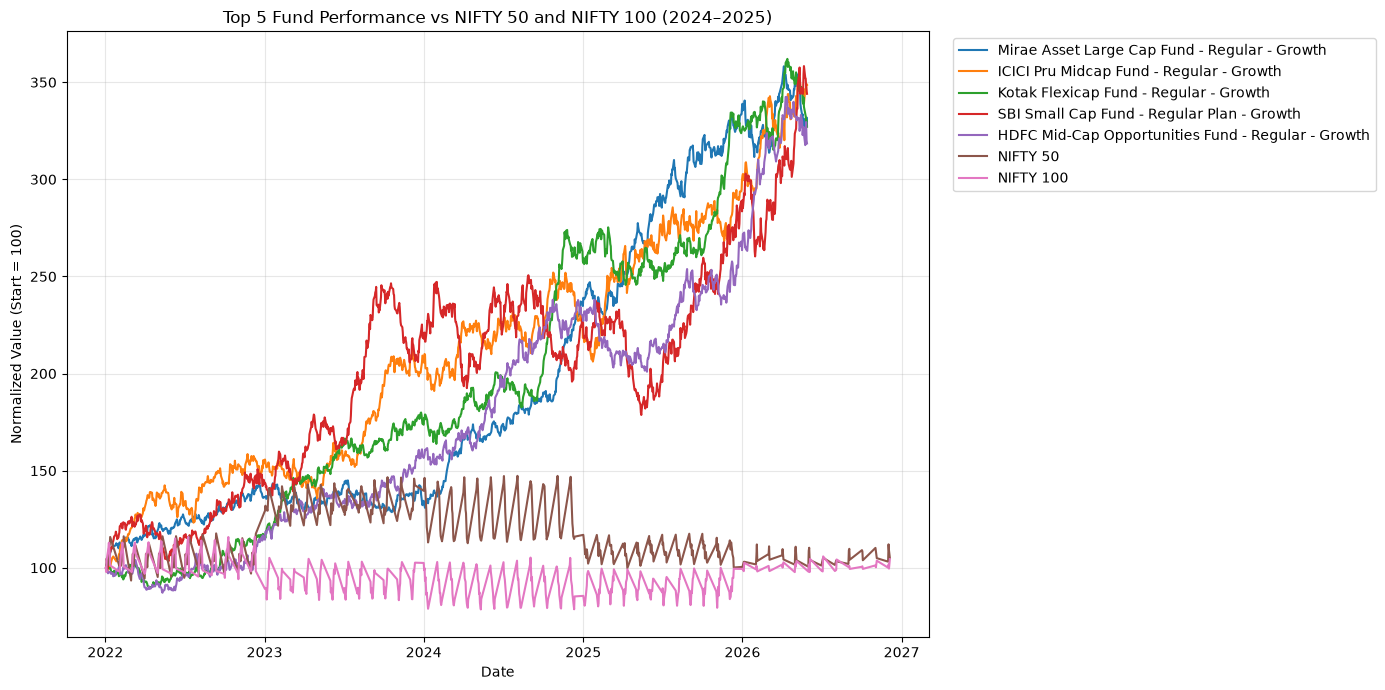

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Plot Top 5 funds
for code in top5_codes:

    fund_data = top5_performance[
        top5_performance["amfi_code"] == code
    ]

    fund_name = top5[
        top5["amfi_code"] == code
    ]["scheme_name"].iloc[0]

    plt.plot(
        fund_data["date"],
        fund_data["normalized"],
        label=fund_name
    )

# Plot NIFTY 50
nifty50_plot = benchmark_performance[
    benchmark_performance["index_name"] == "NIFTY50"
]

plt.plot(
    nifty50_plot["date"],
    nifty50_plot["normalized"],
    label="NIFTY 50"
)

# Plot NIFTY 100
nifty100_plot = benchmark_performance[
    benchmark_performance["index_name"] == "NIFTY100"
]

plt.plot(
    nifty100_plot["date"],
    nifty100_plot["normalized"],
    label="NIFTY 100"
)

plt.title(
    "Top 5 Fund Performance vs NIFTY 50 and NIFTY 100 (2024–2025)"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Start = 100)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [65]:
# Calculate Tracking Error

tracking_error_results = []

for code in top5_codes:

    fund_name = top5[
        top5["amfi_code"] == code
    ]["scheme_name"].iloc[0]

    fund_returns = top5_nav[
        top5_nav["amfi_code"] == code
    ][
        ["date", "nav"]
    ].copy()

    fund_returns = fund_returns.sort_values("date")

    fund_returns["fund_return"] = (
        fund_returns["nav"].pct_change()
    )

    for benchmark_name in ["NIFTY50", "NIFTY100"]:

        benchmark_returns = benchmark_prices[
            benchmark_prices["index_name"] == benchmark_name
        ][
            ["date", "benchmark_return"]
        ].copy()

        merged = fund_returns.merge(
            benchmark_returns,
            on="date",
            how="inner"
        ).dropna()

        tracking_error = (
            (
                merged["fund_return"]
                - merged["benchmark_return"]
            ).std()
            * np.sqrt(252)
        )

        tracking_error_results.append({
            "amfi_code": code,
            "scheme_name": fund_name,
            "benchmark": benchmark_name,
            "tracking_error": tracking_error
        })

tracking_error_df = pd.DataFrame(
    tracking_error_results
)

display(
    tracking_error_df.round(4)
)

,amfi_code,scheme_name,benchmark,tracking_error
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,1.076300
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,1.068200
2,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,1.102100
3,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,1.088500
4,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY50,1.077300
5,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY100,1.057800
6,119598,SBI Small Cap Fund - Regular Plan - Growth,NIFTY50,1.103600
7,119598,SBI Small Cap Fund - Regular Plan - Growth,NIFTY100,1.079000
8,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,1.089000
9,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,1.075000


In [66]:
print(
    "Tracking error rows:",
    len(tracking_error_df)
)

print(
    "Missing tracking errors:",
    tracking_error_df["tracking_error"].isna().sum()
)

Tracking error rows: 10
Missing tracking errors: 0


In [67]:
alpha_beta_output = "Data/processed/alpha_beta.csv"

alpha_beta_df.to_csv(
    alpha_beta_output,
    index=False
)

print("Saved:", alpha_beta_output)
print("Rows:", len(alpha_beta_df))

Saved: Data/processed/alpha_beta.csv
Rows: 40


In [68]:
plt.savefig(
    "reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

FileNotFoundError: [Errno 2] No such file or directory: 'reports/benchmark_comparison.png'

<Figure size 640x480 with 0 Axes>

In [70]:
import os

os.makedirs("reports", exist_ok=True)

print("Reports folder ready.")

Reports folder ready.


In [71]:
plt.savefig(
    "reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

print("Chart saved successfully.")

Chart saved successfully.


<Figure size 640x480 with 0 Axes>

In [72]:
import os

files = [
    "Data/processed/fund_scorecard.csv",
    "Data/processed/alpha_beta.csv",
    "reports/benchmark_comparison.png"
]

for file in files:
    print(
        "✅" if os.path.exists(file) else "❌",
        file
    )

✅ Data/processed/fund_scorecard.csv
✅ Data/processed/alpha_beta.csv
✅ reports/benchmark_comparison.png


In [73]:
git remote -v

SyntaxError: invalid syntax (1081152809.py, line 1)